In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

from scipy.stats import norm
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats.qmc import LatinHypercube

import shap
import warnings
from sklearn.exceptions import ConvergenceWarning

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Helper Functions

In [3]:
def compute_ucb(mu, sigma, kappa=2.5):
    """Compute Upper Confidence Bound acquisition function"""
    return mu + kappa * sigma

def compute_ei(mu, sigma, f_best, xi=0.01):
    """Compute Expected Improvement acquisition function"""
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei

def format_query(point, decimals=6):
    """Format point for portal submission"""
    point_clipped = np.clip(point, 0, 0.999999)
    return '-'.join([f'{x:.{decimals}f}' for x in point_clipped])

def analyze_improvement(outputs):
    """Analyze if last query improved over previous best"""
    if len(outputs) < 2:
        return None, None
    last_output = outputs[-1]
    previous_best = outputs[:-1].max()
    improvement = last_output - previous_best
    return improvement, last_output >= previous_best

# Function 1 - week 3

Function 1 - week 3

Week 3 suggested query: [0.694651, 0.629916]

Week 3 Query formatted: 0.694651-0.629916


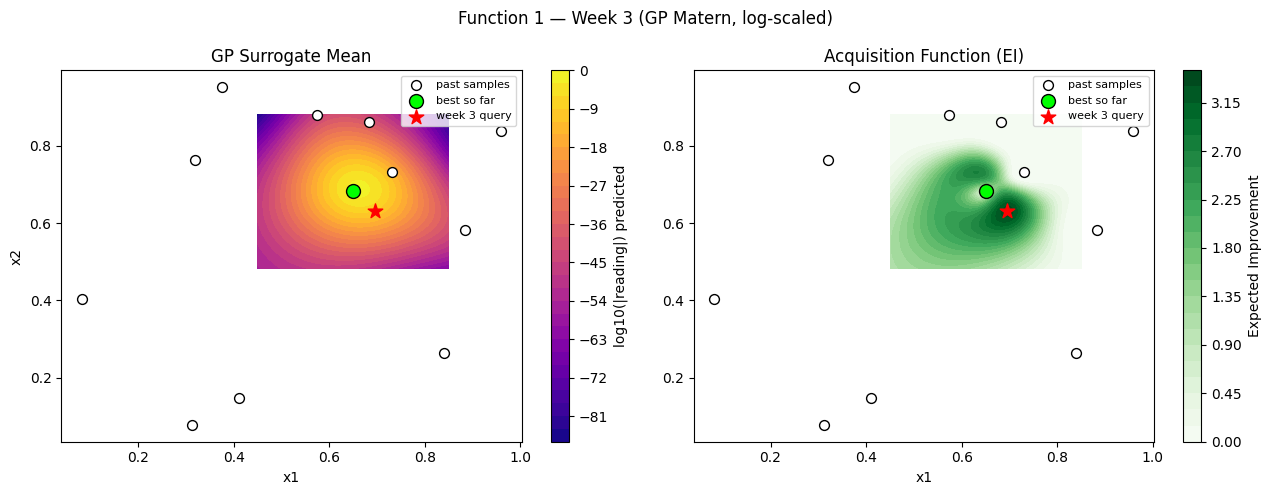

In [18]:
print("Function 1 - week 3\n")
# load initial data
inputs = np.load('../Data/function_1/initial_inputs.npy')
outputs = np.load('../Data/function_1/initial_outputs.npy')

# add week 1 and week 2 results
week1_query = np.array([[0.959184, 0.836735]])
week1_output = np.array([-5.909566597235814e-107])

week2_query = np.array([[0.374540, 0.950714]])
week2_output = np.array([-1.560646704467778e-117])

locations = np.vstack([inputs, week1_query, week2_query])
readings = np.hstack([outputs, week1_output, week2_output])

# log-scale the inputs so the GP sees a sensible range (-124 to -2)
log_readings = np.log10(np.abs(readings) + 1e-300)

# fit a GP with Matern kernel on the log-scaled readings
kernel = Matern(nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp.fit(locations, log_readings)

# search within +-0.2 of the best observed point
best_location = locations[np.argmax(log_readings)]
radius = 0.2

x_min, x_max = max(0, best_location[0] - radius), min(1, best_location[0] + radius)
y_min, y_max = max(0, best_location[1] - radius), min(1, best_location[1] + radius)

np.random.seed(42)
search_points = np.random.uniform(low=[x_min, y_min], high=[x_max, y_max], size=(5000, 2))

mu, sigma = gp.predict(search_points, return_std=True)
current_best = log_readings.max()
ei_scores = compute_ei(mu, sigma, current_best)
next_query = search_points[np.argmax(ei_scores)]

print(f"Week 3 suggested query: [{next_query[0]:.6f}, {next_query[1]:.6f}]")
print(f"\nWeek 3 Query formatted: {format_query(next_query)}")

# plot surrogate mean and EI side by side
n = 100
xx, yy = np.meshgrid(np.linspace(x_min, x_max, n), np.linspace(y_min, y_max, n))
plot_points = np.c_[xx.ravel(), yy.ravel()]

mu_plot, sigma_plot = gp.predict(plot_points, return_std=True)
ei_plot = compute_ei(mu_plot, sigma_plot, current_best)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].contourf(xx, yy, mu_plot.reshape(n, n), levels=30, cmap='plasma')
axes[0].scatter(locations[:,0], locations[:,1], c='white', s=50, edgecolors='black', zorder=5, label='past samples')
axes[0].scatter(*best_location, c='lime', s=100, edgecolors='black', zorder=6, label='best so far')
axes[0].scatter(*next_query, c='red', s=120, marker='*', zorder=7, label='week 3 query')
plt.colorbar(im0, ax=axes[0]).set_label('log10(|reading|) predicted')
axes[0].set_title('GP Surrogate Mean')
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')
axes[0].legend(fontsize=8)

im1 = axes[1].contourf(xx, yy, ei_plot.reshape(n, n), levels=30, cmap='Greens')
axes[1].scatter(locations[:,0], locations[:,1], c='white', s=50, edgecolors='black', zorder=5, label='past samples')
axes[1].scatter(*best_location, c='lime', s=100, edgecolors='black', zorder=6, label='best so far')
axes[1].scatter(*next_query, c='red', s=120, marker='*', zorder=7, label='week 3 query')
plt.colorbar(im1, ax=axes[1]).set_label('Expected Improvement')
axes[1].set_title('Acquisition Function (EI)')
axes[1].set_xlabel('x1')
axes[1].legend(fontsize=8)

plt.suptitle('Function 1 — Week 3 (GP Matern, log-scaled)', fontsize=12)
plt.tight_layout()
plt.savefig('week3_gp.png', dpi=150, bbox_inches='tight')
plt.show()

# Function 2 - Week 3

Function 2 - week 3



/Users/odes_to_knavery/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


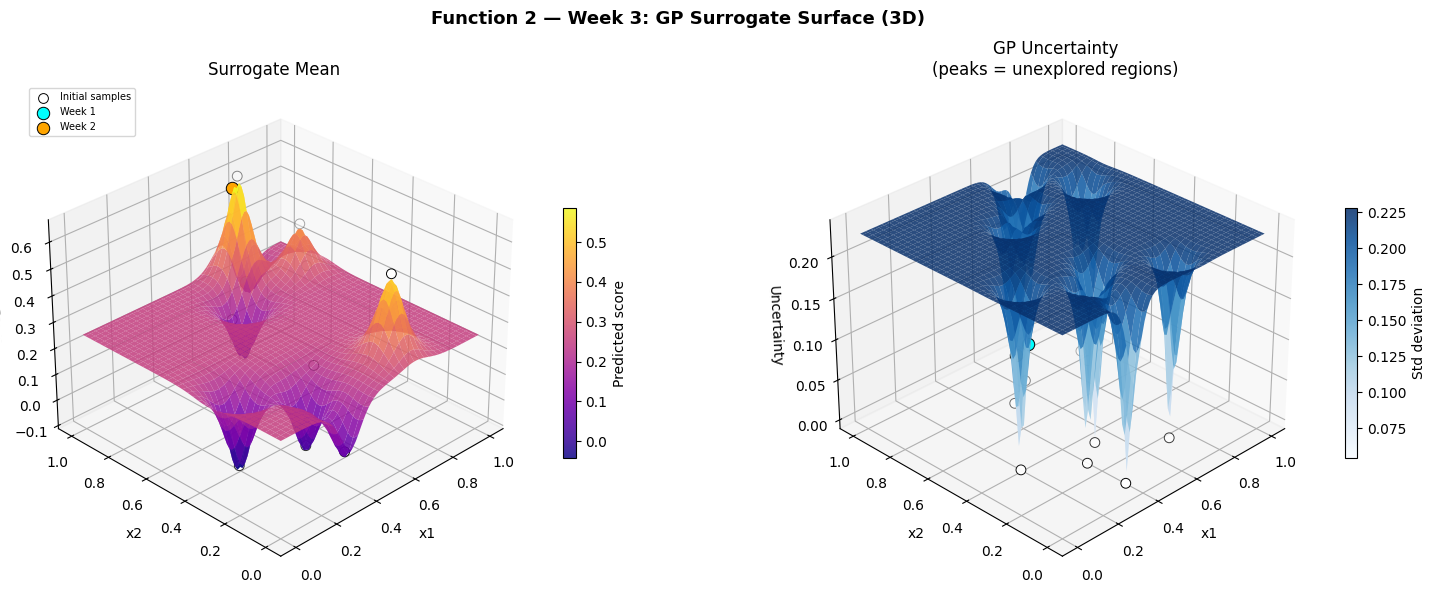

In [19]:
print("Function 2 - week 3\n")
# load initial data
initial_inputs  = np.load('../Data/function_2/initial_inputs.npy')
initial_outputs = np.load('../Data/function_2/initial_outputs.npy')

week1_input  = np.array([[0.775510, 0.959184]])
week1_output = np.array([0.16576674])

week2_input  = np.array([[0.683114, 0.932567]])
week2_output = np.array([0.56974583])

all_inputs  = np.vstack([initial_inputs, week1_input, week2_input])
all_outputs = np.hstack([initial_outputs, week1_output, week2_output])

# fir GP for diagnostic
kernel = Matern(nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, normalize_y=True)
gp.fit(all_inputs, all_outputs)

# build surface
grid_size = 80
xx, yy = np.meshgrid(np.linspace(0, 1, grid_size), np.linspace(0, 1, grid_size))
grid   = np.c_[xx.ravel(), yy.ravel()]

gp_mean, gp_std = gp.predict(grid, return_std=True)
mean_surface = gp_mean.reshape(grid_size, grid_size)
std_surface  = gp_std.reshape(grid_size, grid_size)

# plot surrogate mean surface
fig = plt.figure(figsize=(16, 6))
fig.suptitle('Function 2 — Week 3: GP Surrogate Surface (3D)', fontsize=13, fontweight='bold')

# Plot left surrogate mean surface 
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(xx, yy, mean_surface, cmap='plasma', alpha=0.85, linewidth=0)
fig.colorbar(surf1, ax=ax1, shrink=0.5, label='Predicted score')

# plot all sample points floating above the surface
ax1.scatter(initial_inputs[:, 0], initial_inputs[:, 1],
            all_outputs[:10] + 0.02,
            c='white', s=50, edgecolors='black', linewidths=0.7,
            zorder=5, label='Initial samples')

ax1.scatter(week1_input[:, 0], week1_input[:, 1],
            week1_output + 0.02,
            c='cyan', s=80, edgecolors='black', linewidths=0.7,
            zorder=6, label='Week 1')

ax1.scatter(week2_input[:, 0], week2_input[:, 1],
            week2_output + 0.02,
            c='orange', s=80, edgecolors='black', linewidths=0.7,
            zorder=6, label='Week 2')

ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.set_zlabel('Score')
ax1.set_title('Surrogate Mean')
ax1.legend(fontsize=7, loc='upper left')
ax1.view_init(elev=30, azim=225)

# plot uncertainty surface 
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(xx, yy, std_surface, cmap='Blues', alpha=0.85, linewidth=0)
fig.colorbar(surf2, ax=ax2, shrink=0.5, label='Std deviation')

ax2.scatter(initial_inputs[:, 0], initial_inputs[:, 1],
            np.zeros(10) + 0.005,
            c='white', s=50, edgecolors='black', linewidths=0.7, zorder=5)

ax2.scatter(week1_input[:, 0], week1_input[:, 1],
            [0.005], c='cyan', s=80, edgecolors='black', linewidths=0.7, zorder=6)

ax2.scatter(week2_input[:, 0], week2_input[:, 1],
            [0.005], c='orange', s=80, edgecolors='black', linewidths=0.7, zorder=6)

ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('Uncertainty')
ax2.set_title('GP Uncertainty\n(peaks = unexplored regions)')
ax2.view_init(elev=30, azim=225)

plt.tight_layout()
plt.show()

Function 2 - week 3

Total points:   12
Output range:   [-0.066, 0.611]
Current best:   0.611
Learned kernel: Matern(length_scale=0.0568, nu=2.5) + WhiteKernel(noise_level=0.001)

Week 3 Query:   x1=0.794441, x2=0.256481

Week 3 Query formatted: 0.794441-0.256481
Predicted mean: 0.259
Predicted std:  0.228
EI score:       0.005370
Distance:       0.1847


/Users/odes_to_knavery/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


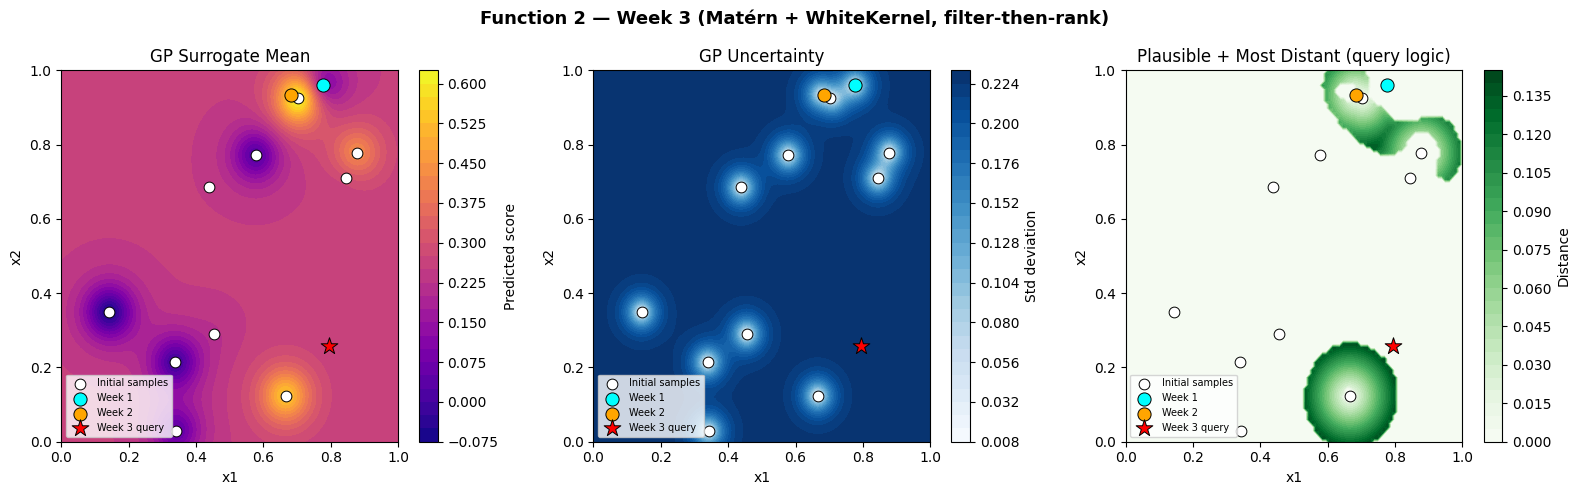


Plot saved as function2_week3.png


In [20]:
print("Function 2 - week 3\n")
# load initial data
initial_inputs  = np.load('../Data/function_2/initial_inputs.npy')
initial_outputs = np.load('../Data/function_2/initial_outputs.npy')

week1_input  = np.array([[0.775510, 0.959184]])
week1_output = np.array([0.16576674])

week2_input  = np.array([[0.683114, 0.932567]])
week2_output = np.array([0.56974583])

all_inputs  = np.vstack([initial_inputs, week1_input, week2_input])
all_outputs = np.hstack([initial_outputs, week1_output, week2_output])

print(f"Total points:   {len(all_outputs)}")
print(f"Output range:   [{all_outputs.min():.3f}, {all_outputs.max():.3f}]")
print(f"Current best:   {all_outputs.max():.3f}")


# Gaussian Process - Matern and WhiteKernel
kernel = Matern(nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, normalize_y=True)
gp.fit(all_inputs, all_outputs)
print(f"Learned kernel: {gp.kernel_}")

# query generation
np.random.seed(42)
candidates = np.random.uniform(0, 1, (20000, 2))

predicted_mean, predicted_std = gp.predict(candidates, return_std=True)
ei_scores    = compute_ei(predicted_mean, predicted_std, all_outputs.max())
min_distance = cdist(candidates, all_inputs).min(axis=1)

# keep only the top 10% of candidates by EI
ei_threshold    = np.percentile(ei_scores, 85)
plausible       = ei_scores >= ei_threshold

# among those, pick the most distant from existing samples
distance_filter = min_distance.copy()
distance_filter[~plausible] = -1

best_index    = np.argmax(distance_filter)
week3_query = candidates[best_index]

print(f"\nWeek 3 Query:   x1={week3_query[0]:.6f}, x2={week3_query[1]:.6f}")
print(f"\nWeek 3 Query formatted: {format_query(week3_query)}")

print(f"Predicted mean: {predicted_mean[best_index]:.3f}")
print(f"Predicted std:  {predicted_std[best_index]:.3f}")
print(f"EI score:       {ei_scores[best_index]:.6f}")
print(f"Distance:       {min_distance[best_index]:.4f}")

# --- plot
grid_size = 100
xx, yy = np.meshgrid(np.linspace(0, 1, grid_size), np.linspace(0, 1, grid_size))
grid   = np.c_[xx.ravel(), yy.ravel()]

gp_mean, gp_std = gp.predict(grid, return_std=True)
ei_grid      = compute_ei(gp_mean, gp_std, all_outputs.max())
dist_grid    = cdist(grid, all_inputs).min(axis=1)

# show where plausible + distant candidates are
ei_thresh_grid  = np.percentile(ei_grid, 90)
combined        = np.where(ei_grid >= ei_thresh_grid, dist_grid, 0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Function 2 — Week 3 (Matérn + WhiteKernel, filter-then-rank)',
             fontsize=13, fontweight='bold')

panels = [
    (gp_mean.reshape(grid_size, grid_size), 'plasma', 'GP Surrogate Mean',              'Predicted score'),
    (gp_std.reshape(grid_size, grid_size),  'Blues',  'GP Uncertainty',                 'Std deviation'),
    (combined.reshape(grid_size, grid_size),'Greens', 'Plausible + Most Distant (query logic)', 'Distance'),
]

for ax, (surface, cmap, title, cbar_label) in zip(axes, panels):
    im = ax.contourf(xx, yy, surface, levels=30, cmap=cmap)
    plt.colorbar(im, ax=ax, label=cbar_label)

    ax.scatter(initial_inputs[:, 0], initial_inputs[:, 1],
               c='white', s=60, edgecolors='black', linewidths=0.7,
               zorder=5, label='Initial samples')

    ax.scatter(week1_input[:, 0], week1_input[:, 1],
               c='cyan', s=90, edgecolors='black', linewidths=0.7,
               zorder=6, label='Week 1')

    ax.scatter(week2_input[:, 0], week2_input[:, 1],
               c='orange', s=90, edgecolors='black', linewidths=0.7,
               zorder=6, label='Week 2')

    ax.scatter(week3_query[0], week3_query[1],
               c='red', s=160, marker='*', edgecolors='black', linewidths=0.7,
               zorder=7, label='Week 3 query')

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.savefig('function2_week3.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as function2_week3.png")

# Function 3 - week 3

Function 3 - week 3

Total points: 17
Best result so far: -0.029062
Output range: [-0.398926, -0.029062]

Coefficients:
  A     : -0.2179
  B     : +0.4839
  C     : +0.9458
  A*B   : -0.0924
  A*C   : +0.4143
  B*C   : +0.5395
  A²    : -0.2558
  B²    : -1.2907
  C²    : -0.7023
  Intercept: -0.3158
Learned kernel: Matern(length_scale=0.232, nu=2.5) + WhiteKernel(noise_level=0.0001)

 High C/B region check
  [0.3 0.8 0.9] → mean: -0.1594, std: 0.0796
  [0.2  0.9  0.95] → mean: -0.1417, std: 0.0809
  [0.4  0.7  0.85] → mean: -0.1565, std: 0.0777


/Users/odes_to_knavery/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/odes_to_knavery/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/odes_to_knavery/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GP R²: 0.000 → weight: 0.50
Poly R²: 0.000 → weight: 0.50

Blending: 50% GP (EI) + 50% Polynomial

Week 3 Query: [0.39273511 0.5043807  0.46433174]

Week 3 Query formatted: 0.392735-0.504381-0.464332

Predicted mean: -0.037423
Predicted std:  0.048912
EI score:       0.011692
Poly score:     -0.070747
Blended score:  0.912348


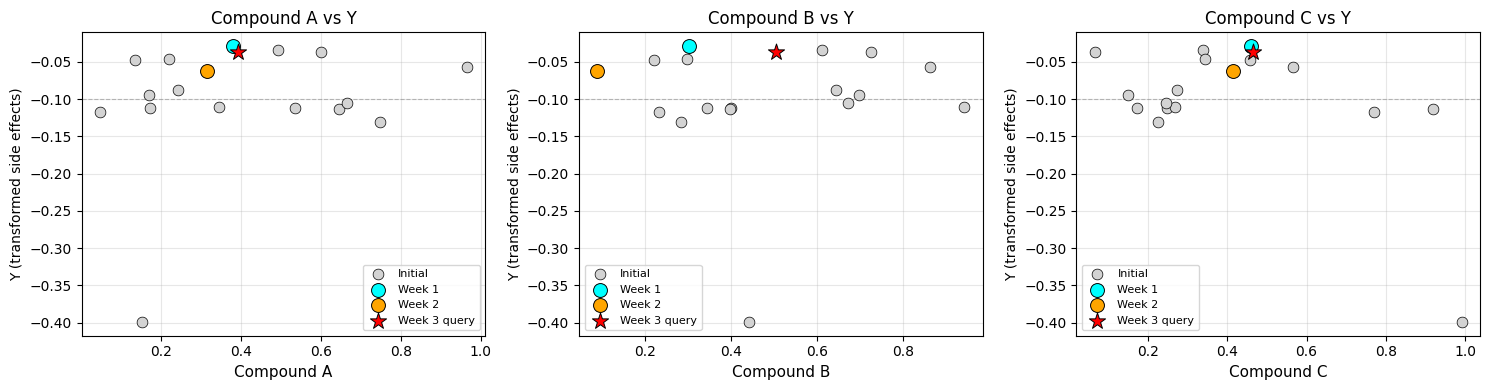

In [21]:
print("Function 3 - week 3\n")
# Load initial data
f3_inputs  = np.load('../Data/function_3/initial_inputs.npy')
f3_outputs = np.load('../Data/function_3/initial_outputs.npy')

week1_input  = np.array([[0.378956, 0.302768, 0.459346]])
week1_output = np.array([-0.02906213067759293])

week2_input  = np.array([[0.315339, 0.088659, 0.415174]])
week2_output = np.array([-0.06230989251412482])

X = np.vstack([f3_inputs, week1_input, week2_input])
Y = np.hstack([f3_outputs, week1_output, week2_output])

print(f"Total points: {len(Y)}")
print(f"Best result so far: {Y.max():.6f}")
print(f"Output range: [{Y.min():.6f}, {Y.max():.6f}]")

# Polynomial Regression (for interpretability)
# Create interaction terms: A, B, C, A*B, A*C, B*C, A², B², C²
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Fit linear regression on expanded features
poly_model = LinearRegression()
poly_model.fit(X_poly, Y)

# Print coefficients
feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A²', 'B²', 'C²']
print("\nCoefficients:")
for name, coefficient in zip(feature_names, poly_model.coef_):
    print(f"  {name:6s}: {coefficient:+.4f}")
print(f"  Intercept: {poly_model.intercept_:.4f}")


# Gaussian Process - Matern and WhiteKernel 
kernel = Matern(nu=2.5, length_scale=0.5) + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-4, 1e-1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
    random_state=42
)

gp.fit(X, Y)
print(f"Learned kernel: {gp.kernel_}")

print("\n High C/B region check")
test_points = np.array([[0.3, 0.8, 0.9],
                         [0.2, 0.9, 0.95],
                         [0.4, 0.7, 0.85]])
test_mean, test_std = gp.predict(test_points, return_std=True)
for i, p in enumerate(test_points):
    print(f"  {p} → mean: {test_mean[i]:.4f}, std: {test_std[i]:.4f}")

#  Generate candidates 
np.random.seed(42)

# Random candidates across the full space
random_candidates = np.random.uniform(0, 1, (5000, 3))

# Local candidates near the best point (Week 1)
best_point_index = np.argmax(Y)
local_candidates = []

for i in range(2000):
    offset = np.random.normal(0, 0.05, 3)
    candidate = np.clip(X[best_point_index] + offset, 0, 1)
    local_candidates.append(candidate)

# Add good candidates from PR, pushing C and B toward their upper range
directed_candidates = np.random.uniform([0, 0.6, 0.7], [1, 1, 1], (4000, 3))

all_candidates = np.vstack([random_candidates, local_candidates, directed_candidates])

# Predict on all candidates
predicted_mean, predicted_std = gp.predict(all_candidates, return_std=True)

# Compute Expected Improvement
ei_scores = compute_ei(predicted_mean, predicted_std, Y.max(), xi=0.01)

# Get polynomial predictions for all candidates
poly_candidates = poly.transform(all_candidates)
poly_predictions = poly_model.predict(poly_candidates)

# Normalize both scores to [0,1] range
ei_normalized = (ei_scores - ei_scores.min()) / (ei_scores.max() - ei_scores.min() + 1e-9)
poly_normalized = (poly_predictions - poly_predictions.min()) / (poly_predictions.max() - poly_predictions.min() + 1e-9)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
gp_cv_scores = cross_val_score(gp, X, Y, cv=cv, scoring='r2')
poly_cv_scores = cross_val_score(poly_model, X_poly, Y, cv=cv, scoring='r2')

gp_r2 = max(gp_cv_scores.mean(), 0)
poly_r2 = max(poly_cv_scores.mean(), 0)

total = gp_r2 + poly_r2

if total == 0:
    gp_weight = 0.5
    poly_weight = 0.5
else:
    gp_weight = gp_r2 / total
    poly_weight = poly_r2 / total

print(f"GP R²: {gp_r2:.3f} → weight: {gp_weight:.2f}")
print(f"Poly R²: {poly_r2:.3f} → weight: {poly_weight:.2f}")

blended_scores = gp_weight * ei_normalized + poly_weight * poly_normalized

print(f"\nBlending: {gp_weight*100:.0f}% GP (EI) + {poly_weight*100:.0f}% Polynomial")

# Select candidate with highest blended score
best_candidate_index = np.argmax(blended_scores)
week3_query = all_candidates[best_candidate_index]


print(f"\nWeek 3 Query: {week3_query}")
print(f"\nWeek 3 Query formatted: {format_query(week3_query)}")


print(f"\nPredicted mean: {predicted_mean[best_candidate_index]:.6f}")
print(f"Predicted std:  {predicted_std[best_candidate_index]:.6f}")
print(f"EI score:       {ei_scores[best_candidate_index]:.6f}")
print(f"Poly score:     {poly_predictions[best_candidate_index]:.6f}")
print(f"Blended score:  {blended_scores[best_candidate_index]:.6f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
compound_names = ['Compound A', 'Compound B', 'Compound C']

for i, ax in enumerate(axes):
    # Original points
    ax.scatter(X[:15, i], Y[:15], c='lightgray', s=60, edgecolors='black', 
               linewidths=0.5, label='Initial', zorder=3)
    
    # Week 1 (best result)
    ax.scatter(week1_input[0, i], week1_output[0], c='cyan', s=100, 
               edgecolors='black', linewidths=0.7, label='Week 1', zorder=4)
    
    # Week 2
    ax.scatter(week2_input[0, i], week2_output[0], c='orange', s=100, 
               edgecolors='black', linewidths=0.7, label='Week 2', zorder=5)
    
    # Week 3 suggested query
    ax.scatter(week3_query[i], predicted_mean[best_candidate_index], 
               c='red', s=150, marker='*', edgecolors='black', 
               linewidths=0.7, label='Week 3 query', zorder=6)
    
    ax.set_xlabel(compound_names[i], fontsize=11)
    ax.set_ylabel('Y (transformed side effects)', fontsize=10)
    ax.set_title(f'{compound_names[i]} vs Y')
    ax.axhline(Y.mean(), color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Function 4 - week 3

In [22]:
print("Function 4 - Week 3\n")

# load initial data
f4_inputs  = np.load('../Data/function_4/initial_inputs.npy')
f4_outputs = np.load('../Data/function_4/initial_outputs.npy')

# add week 1 and week 2 observations
week1_input  = np.array([[0.466173, 0.451984, 0.359193, 0.383111]])
week1_output = np.array([-0.9654345395220925])
week2_input  = np.array([[0.424201, 0.406375, 0.372722, 0.413313]])
week2_output = np.array([0.6308582112564989])
all_inputs   = np.vstack([f4_inputs, week1_input, week2_input])
all_outputs  = np.hstack([f4_outputs, week1_output, week2_output])

print(f"Total points: {all_inputs.shape[0]}")
print(f"Current best: {all_outputs.max():.4f}")

candidate_kernels = {
    'Matern(nu=2.5) global':            Matern(length_scale=0.5, length_scale_bounds=(0.001, 10.0), nu=2.5),
    'Matern(nu=2.5) ARD':               Matern(length_scale=[0.5, 0.5, 0.5, 0.5], length_scale_bounds=(0.001, 10.0), nu=2.5),
    'Matern(nu=2.5) ARD + WhiteKernel': Matern(length_scale=[0.5, 0.5, 0.5, 0.5], length_scale_bounds=(0.001, 10.0), nu=2.5) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-6, 1.0)),
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kernel_results = {}

for kernel_name, kernel in candidate_kernels.items():
    gaussian_process_candidate = GaussianProcessRegressor(
        kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True
    )
    cross_validation_scores = cross_val_score(
        gaussian_process_candidate, all_inputs, all_outputs,
        cv=kfold, scoring='r2'
    )
    kernel_results[kernel_name] = {
        'r2_score': cross_validation_scores.mean(),
        'kernel':   kernel
    }
    print(f"{kernel_name}: mean R2 {cross_validation_scores.mean():.4f}")

best_kernel_name = max(kernel_results, key=lambda k: kernel_results[k]['r2_score'])
best_kernel      = kernel_results[best_kernel_name]['kernel']
print(f"\nBest kernel: {best_kernel_name}")

# fit gaussian process on all points using the best kernel
gaussian_process = GaussianProcessRegressor(
    kernel=best_kernel, n_restarts_optimizer=15, alpha=1e-6, normalize_y=True
)
gaussian_process.fit(all_inputs, all_outputs)
print(f"Fitted kernel: {gaussian_process.kernel_}")

# generate candidates uniformly across the space
np.random.seed(42)
candidates = np.random.uniform(0, 1, (10000, 4))

# compute ucb scores across all candidates
predicted_means, predicted_stds = gaussian_process.predict(candidates, return_std=True)
kappa = 2.0
upper_confidence_bound_scores = predicted_means + kappa * predicted_stds

# select the candidate with the highest ucb score
best_candidate_index = np.argmax(upper_confidence_bound_scores)
week3_query          = candidates[best_candidate_index]

print(f"\nWeek 3 Query: {week3_query.round(6).tolist()}")
print(f"\nWeek 3 Query formatted: {format_query(week3_query)}")
print(f"Predicted mean: {predicted_means[best_candidate_index]:.4f}")
print(f"Predicted std:  {predicted_stds[best_candidate_index]:.4f}")
print(f"UCB score:      {upper_confidence_bound_scores[best_candidate_index]:.4f}")
print(f"Distance from Week 2: {np.linalg.norm(week3_query - week2_input[0]):.4f}")

Function 4 - Week 3

Total points: 32
Current best: 0.6309
Matern(nu=2.5) global: mean R2 0.8188


/Users/odes_to_knavery/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Matern(nu=2.5) ARD: mean R2 0.5700


/Users/odes_to_knavery/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/odes_to_knavery/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Matern(nu=2.5) ARD + WhiteKernel: mean R2 0.6616

Best kernel: Matern(nu=2.5) global
Fitted kernel: Matern(length_scale=0.605, nu=2.5)

Week 3 Query: [0.413541, 0.373697, 0.536536, 0.453354]

Week 3 Query formatted: 0.413541-0.373697-0.536536-0.453354
Predicted mean: 0.0463
Predicted std:  1.3407
UCB score:      2.7276
Distance from Week 2: 0.1721


/Users/odes_to_knavery/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


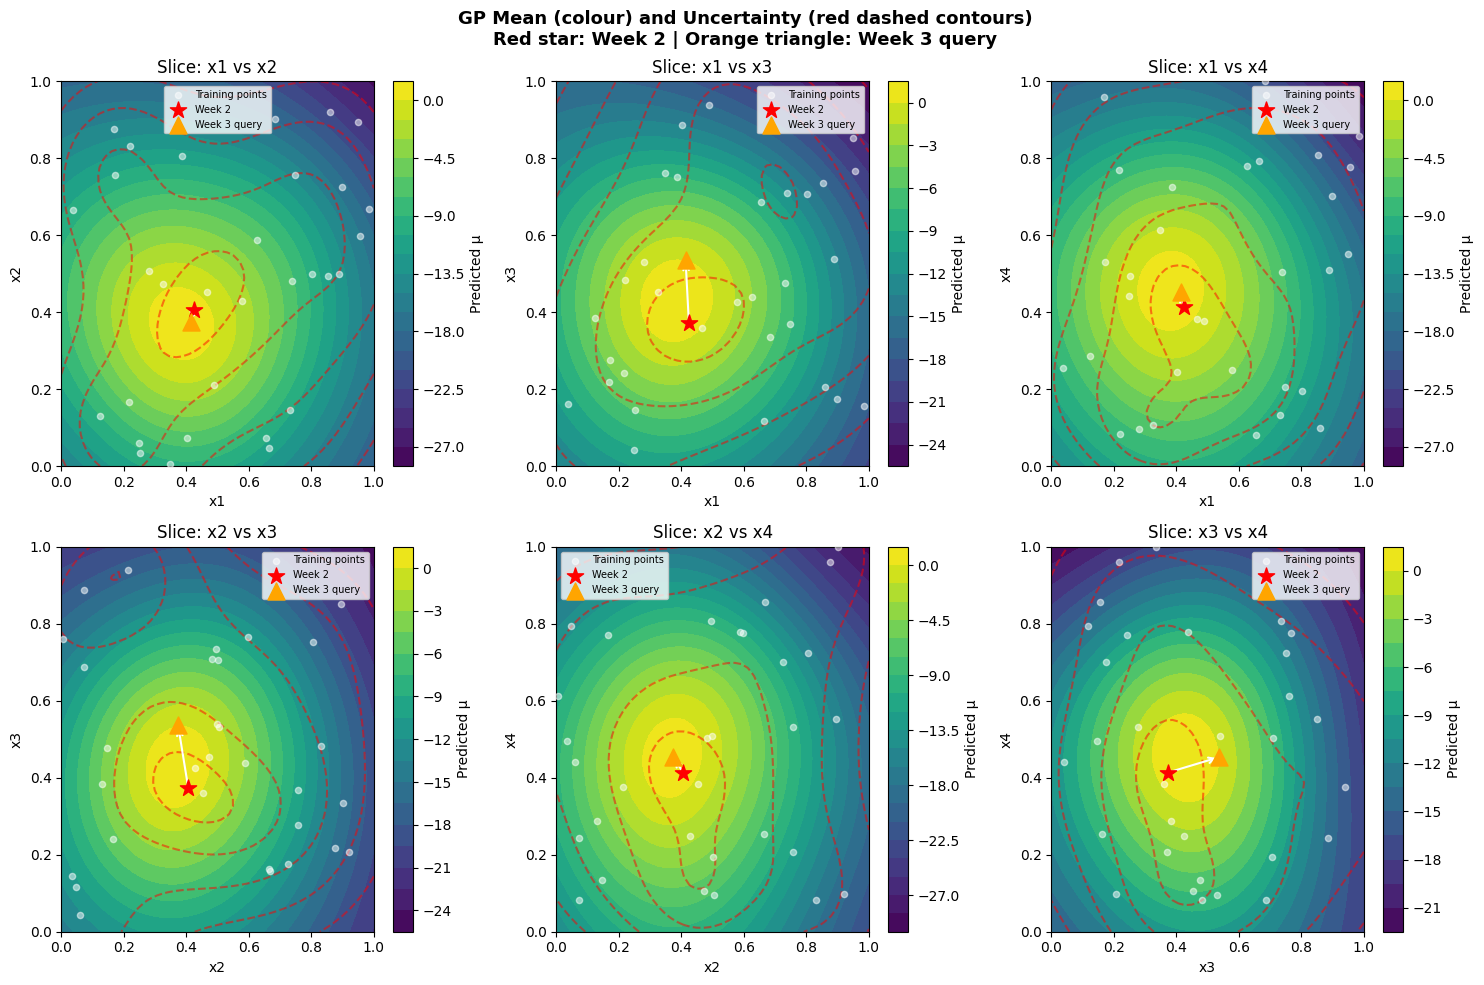

In [23]:
import itertools
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

dimension_pairs = list(itertools.combinations(range(4), 2))
dimension_names = ['x1', 'x2', 'x3', 'x4']
week2_point = week2_input[0]
week3_point = week3_query

for plot_index, (dim_a, dim_b) in enumerate(dimension_pairs):
    ax = axes[plot_index]
    
    # Create grid sliced through Week 2 point
    grid_values = np.linspace(0, 1, 50)
    grid_a, grid_b = np.meshgrid(grid_values, grid_values)
    
    # Fix non-varying dims at Week 2 values
    grid_candidates = np.tile(week2_point, (50 * 50, 1))
    grid_candidates[:, dim_a] = grid_a.ravel()
    grid_candidates[:, dim_b] = grid_b.ravel()
    
    # Predict using best GP
    grid_means, grid_stds = gaussian_process.predict(grid_candidates, return_std=True)
    grid_means_2d = grid_means.reshape(50, 50)
    grid_stds_2d  = grid_stds.reshape(50, 50)
    
    # Plot mean and uncertainty
    mean_plot = ax.contourf(grid_a, grid_b, grid_means_2d, levels=20, cmap='viridis')
    ax.contour(grid_a, grid_b, grid_stds_2d, levels=5, 
               colors='red', alpha=0.5, linestyles='dashed')
    plt.colorbar(mean_plot, ax=ax, label='Predicted μ')
    
    # Training points
    ax.scatter(all_inputs[:, dim_a], all_inputs[:, dim_b],
               color='white', s=20, alpha=0.5, zorder=4, label='Training points')
    
    # Week 2 point
    ax.scatter(week2_point[dim_a], week2_point[dim_b],
               color='red', s=150, zorder=6, marker='*', label='Week 2')
    
    # Week 3 query
    ax.scatter(week3_point[dim_a], week3_point[dim_b],
               color='orange', s=150, zorder=6, marker='^', label='Week 3 query')
    
    # Arrow showing movement from Week 2 to Week 3
    ax.annotate('', 
                xy=(week3_point[dim_a], week3_point[dim_b]),
                xytext=(week2_point[dim_a], week2_point[dim_b]),
                arrowprops=dict(arrowstyle='->', color='white', lw=1.5))
    
    ax.set_xlabel(dimension_names[dim_a])
    ax.set_ylabel(dimension_names[dim_b])
    ax.set_title(f'Slice: {dimension_names[dim_a]} vs {dimension_names[dim_b]}')
    ax.legend(fontsize=7)

plt.suptitle('GP Mean (colour) and Uncertainty (red dashed contours)\nRed star: Week 2 | Orange triangle: Week 3 query', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Function 5 - week 3

In [24]:
print("Function 5 - Week 3\n")

f5_inputs = np.load('../Data/function_5/initial_inputs.npy')
f5_outputs = np.load('../Data/function_5/initial_outputs.npy')

print("X shape:", f5_inputs.shape)
print("Y shape:", f5_outputs.shape)

week1_query = np.array([[0.284290, 0.869208, 0.999999, 0.903273]])
week1_output = np.array([2201.834589108927])

week2_query = np.array([[0.311208, 0.881577, 0.999999, 0.915050]])
week2_output = np.array([2381.536867607932])

inputs = np.vstack([f5_inputs, week1_query, week2_query])
outputs = np.hstack([f5_outputs, week1_output, week2_output])

print(f"All X: {inputs.shape[0]} points")
print(f"All Y: {outputs.shape[0]} points")
print(f"Output range: [{outputs.min():.2f}, {outputs.max():.2f}]")

# scale inputs for SVR - important for RBF kernel
input_scaler = StandardScaler()
scaled_inputs = input_scaler.fit_transform(inputs)

output_scaler = StandardScaler()
scaled_outputs = output_scaler.fit_transform(outputs.reshape(-1, 1)).ravel()


# linear regression to understand which directions to push
linear_model = LinearRegression()
linear_model.fit(inputs, outputs)

print("Linear regression coefficients:")
for i, coef in enumerate(linear_model.coef_):
    print(f"  x{i+1}: {coef:.2f}")


# SVR with RBF kernel to capture input combinations
svr_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_model.fit(scaled_inputs, scaled_outputs)


# GP
kernel = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp_model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6, normalize_y=True)
gp_model.fit(inputs, outputs)


# generate candidates: local search around the best point with radius
best_point = inputs[np.argmax(outputs)]
np.random.seed(42)

local_candidates = []
for _ in range(8000):
    candidate = best_point + np.random.normal(0, 0.05, 4)
    candidate = np.clip(candidate, 0, 0.9999)
    local_candidates.append(candidate)

# directional candidates nudging positive coefficient dimensions more aggressively
directional_candidates = []
for _ in range(2000):
    candidate = best_point.copy()
    for dimension in range(4):
        if linear_model.coef_[dimension] > 0:
            candidate[dimension] = min(candidate[dimension] + abs(np.random.normal(0, 0.05)), 1.0)
        else:
            candidate[dimension] = max(candidate[dimension] + np.random.normal(0, 0.02), 0.0)
    directional_candidates.append(candidate)

candidates = np.vstack([local_candidates, directional_candidates])


# SVR pre-filter: keep top 3000 candidates by predicted yield
scaled_candidates = input_scaler.transform(candidates)
svr_predictions = output_scaler.inverse_transform(
    svr_model.predict(scaled_candidates).reshape(-1, 1)
).ravel()

top_indices = np.argsort(svr_predictions)[-3000:]
filtered_candidates = candidates[top_indices]


# GP + EI on the filtered candidates
mean, std = gp_model.predict(filtered_candidates, return_std=True)
ei_scores = compute_ei(mean, std, outputs.max(), xi=0.005)

best_index = np.argmax(ei_scores)
query = filtered_candidates[best_index]

print(f"\nWeek 3 query: {query}")
print(f"\nWeek 3 Query formatted: {format_query(query)}")
print(f"GP mean: {mean[best_index]:.2f}")
print(f"GP std: {std[best_index]:.2f}")
print(f"SVR prediction: {svr_predictions[top_indices[best_index]]:.2f}")
print(f"EI score: {ei_scores[best_index]:.6f}")

Function 5 - Chemical Yield

X shape: (20, 4)
Y shape: (20,)
All X: 22 points
All Y: 22 points
Output range: [0.11, 2381.54]
Linear regression coefficients:
  x1: -203.78
  x2: 671.36
  x3: 1287.93
  x4: 837.21

Week 3 query: [0.35508538 0.89916012 0.9999     0.93419609]

Week 3 Query formatted: 0.355085-0.899160-0.999900-0.934196
GP mean: 2498.08
GP std: 68.52
SVR prediction: 2561.17
EI score: 117.793459


# Function 6 - week 3

In [25]:
print("Function 6 - Week 3\n")
# load data

f6_inputs = np.load('../Data/function_6/initial_inputs.npy')
f6_outputs = np.load('../Data/function_6/initial_outputs.npy')

prev_queries = np.array([
    [0.201818, 0.220639, 0.476414, 0.867793, 0.023115], 
    [0.457382, 0.349799, 0.529520, 0.691032, 0.192589]   
])
prev_outputs = np.array([
    -0.792246,   
    -0.361637    
])

all_inputs  = np.vstack([f6_inputs, prev_queries])
all_outputs = np.hstack([f6_outputs, prev_outputs])

print(f"Total observations : {all_inputs.shape[0]}")
print(f"Output range       : [{all_outputs.min():.3f}, {all_outputs.max():.3f}]")
print(f"Current best       : {all_outputs.max():.3f}  (goal: 0)")

# Gaussian Process with ARD Kernel
kernel = ConstantKernel(1.0, (0.001, 1000)) * Matern(
    length_scale       = [1.0, 1.0, 1.0, 1.0, 1.0],    # one per ingredient
    length_scale_bounds= (0.05, 5.0),                   
    nu                 = 2.5                           
)

gp = GaussianProcessRegressor(
    kernel             = kernel,
    n_restarts_optimizer = 25,    
    alpha              = 0.00001, 
    normalize_y        = True     
)

gp.fit(all_inputs, all_outputs)

fitted_length_scales = np.round(gp.kernel_.k2.length_scale, 3)
print(f"\nFitted ARD length scales per ingredient:")
ingredient_names = ["x1 (ingredient 1)", "x2 (ingredient 2)", "x3 (ingredient 3)", "x4 (ingredient 4)", "x5 (ingredient 5)"]
for name, ls in zip(ingredient_names, fitted_length_scales):
    print(f"  {name}: {ls:.3f}")

# Candidate Generation 
np.random.seed(42)

# 1. Broad random search across full space
random_candidates = np.random.uniform(0, 1, (10000, 5))

# 2. Latin Hypercube-style spread for better space coverage
sampler       = LatinHypercube(d=5, seed=42)
lhs_candidates = sampler.random(n=5000)

# 3. Random noise around the top 5 observed points
near_best = []
top_indices = np.argsort(all_outputs)[-5:][::-1]
for index in top_indices:
    for _ in range(400):
        random_noise = np.random.normal(0, 0.07, 5)
        candidate    = np.clip(all_inputs[index] + random_noise, 0, 1)
        near_best.append(candidate)

candidates = np.vstack([
    random_candidates,
    lhs_candidates,
    np.array(near_best)
])
print(f"\nTotal candidates evaluated: {candidates.shape[0]}")

# Acquisition Function: Expected Improvement
mu, sigma = gp.predict(candidates, return_std=True)
ei = compute_ei(mu, sigma, all_outputs.max(), xi=0.05)

best_index = np.argmax(ei)
query = candidates[best_index]

print(f"\nWeek 3 Query       : {query}")
print(f"\nWeek 3 Query formatted: {format_query(query)}")
print(f"Predicted mean (μ) : {mu[best_index]:.4f}")
print(f"Predicted std  (σ) : {sigma[best_index]:.4f}")
print(f"Expected Improvement: {ei[best_index]:.6f}")

Function 6 - Week 3

Total observations : 22
Output range       : [-2.571, -0.362]
Current best       : -0.362  (goal: 0)

Fitted ARD length scales per ingredient:
  x1 (ingredient 1): 0.591
  x2 (ingredient 2): 1.092
  x3 (ingredient 3): 1.450
  x4 (ingredient 4): 1.360
  x5 (ingredient 5): 1.035

Total candidates evaluated: 17000

Week 3 Query       : [0.50340411 0.32886063 0.6628376  0.99503123 0.02551355]

Week 3 Query formatted: 0.503404-0.328861-0.662838-0.995031-0.025514
Predicted mean (μ) : -0.2279
Predicted std  (σ) : 0.1691
Expected Improvement: 0.117429


# Function 7 - week 3

Function 7 — Week 3

Total data points : 32
Output range      : [0.003, 1.653]
Current best      : 1.6531
Best input        : [0.034389 0.427542 0.236649 0.342956 0.405706 0.695527]
Step 1: Random Forest + SHAP

RF Feature Importance:
  HP1: 0.690
  HP2: 0.063
  HP3: 0.040
  HP4: 0.019
  HP5: 0.110
  HP6: 0.078

Mean absolute SHAP values (overall influence):
  HP1: 0.188
  HP2: 0.034
  HP3: 0.018
  HP4: 0.008
  HP5: 0.064
  HP6: 0.045

Feature direction (top 25% mean vs dataset mean):
  HP1: top mean 0.256 vs dataset mean 0.481  ->  push low
  HP2: top mean 0.433 vs dataset mean 0.401  ->  push high
  HP3: top mean 0.501 vs dataset mean 0.383  ->  push high
  HP4: top mean 0.480 vs dataset mean 0.495  ->  push low
  HP5: top mean 0.313 vs dataset mean 0.464  ->  push low
  HP6: top mean 0.654 vs dataset mean 0.496  ->  push high
Step 2: Subspace Definition

Subspace bounds (RF importance controls width, direction controls placement):
  HP1: [0.020, 0.310]  (importance 0.690, push low)


/Users/odes_to_knavery/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/odes_to_knavery/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Week 3 suggested query: [0.02       0.06263544 0.5873674  0.31322538 0.36200812 0.6645393 ]

Week 3 Query formatted: 0.020000-0.062635-0.587367-0.313225-0.362008-0.664539

GP predicted Y (original scale) : 1.6252
GP uncertainty (log scale std)  : 0.0672


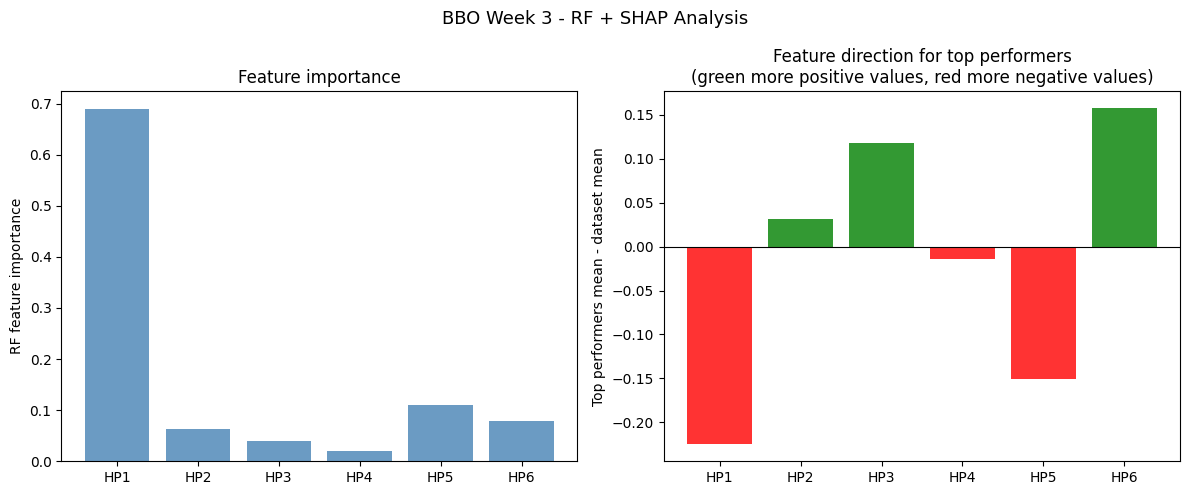

In [26]:
print("Function 7 — Week 3\n")
# load data
f7_inputs = np.load('../Data/function_7/initial_inputs.npy')
f7_outputs = np.load('../Data/function_7/initial_outputs.npy')

week1_query = np.array([[0.045091, 0.528666, 0.329265, 0.105350, 0.434671, 0.641164]])
week1_output = np.array([1.0510006614196026])
week2_query = np.array([[0.034389, 0.427542, 0.236649, 0.342956, 0.405706, 0.695527]])
week2_output = np.array([1.6531363312716738])

all_inputs = np.vstack([f7_inputs, week1_query, week2_query])
all_outputs = np.hstack([f7_outputs, week1_output, week2_output])

feature_names = [f"HP{i+1}" for i in range(6)]

print(f"Total data points : {len(all_outputs)}")
print(f"Output range      : [{all_outputs.min():.3f}, {all_outputs.max():.3f}]")
print(f"Current best      : {all_outputs.max():.4f}")
print(f"Best input        : {all_inputs[np.argmax(all_outputs)]}")


# Step 1: RF + SHAP
print("Step 1: Random Forest + SHAP")
random_forest = RandomForestRegressor(n_estimators=200, random_state=42)
random_forest.fit(all_inputs, all_outputs)

print("\nRF Feature Importance:")
for name, importance in zip(feature_names, random_forest.feature_importances_):
    print(f"  {name}: {importance:.3f}")

explainer = shap.TreeExplainer(random_forest)
shap_values = explainer.shap_values(all_inputs)

top_performers_mask = all_outputs >= np.percentile(all_outputs, 75)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

print("\nMean absolute SHAP values (overall influence):")
for name, value in zip(feature_names, mean_abs_shap):
    print(f"  {name}: {value:.3f}")

# Direction: compare top performers' mean feature values against dataset mean.
# If top performers have lower HP1 than average, the direction for HP1 is low.
dataset_mean = all_inputs.mean(axis=0)
top_mean     = all_inputs[top_performers_mask].mean(axis=0)
push_high    = top_mean > dataset_mean

print(f"\nFeature direction (top 25% mean vs dataset mean):")
for name, top, avg, high in zip(feature_names, top_mean, dataset_mean, push_high):
    direction = "high" if high else "low"
    print(f"  {name}: top mean {top:.3f} vs dataset mean {avg:.3f}  ->  push {direction}")


# Step 2: Subspace definition
# High importance = narrow window. Low importance = wide window.
# Direction from step 1 controls where that window sits in the 0-1 range.
print("Step 2: Subspace Definition")

constraint_width = 1.0 - random_forest.feature_importances_

subspace_lower = np.where(push_high, 1.0 - constraint_width, 0.02)
subspace_upper = np.where(push_high, 1.0, constraint_width)
subspace_lower = np.clip(subspace_lower, 0, 1)
subspace_upper = np.clip(subspace_upper, 0, 1)

print("\nSubspace bounds (RF importance controls width, direction controls placement):")
for name, low, high, importance, direction in zip(
    feature_names, subspace_lower, subspace_upper,
    random_forest.feature_importances_, push_high
):
    label = "high" if direction else "low"
    print(f"  {name}: [{low:.3f}, {high:.3f}]  (importance {importance:.3f}, push {label})")


# Step 3: GP with EI inside the subspace
print("Step 3: GP with Expected Improvement")

kernel = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
)
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
)
gp.fit(all_inputs, np.log1p(all_outputs))


def negative_ei(candidate, gp, best_output, xi=0.01):
    candidate = candidate.reshape(1, -1)
    mean, std = gp.predict(candidate, return_std=True)
    # Comparison must be in log scale since the GP was fitted on log1p outputs
    best_log = np.log1p(best_output)
    if std[0] == 0:
        return 0.0
    improvement = mean - best_log - xi
    z = improvement / std
    ei = improvement * norm.cdf(z) + std * norm.pdf(z)
    return -ei[0]  # negative because scipy minimises


best_output_so_far = all_outputs.max()
bounds = list(zip(subspace_lower, subspace_upper))

best_ei_value = np.inf
best_candidate = None

np.random.seed(42)
for _ in range(500):
    start = np.array([np.random.uniform(low, high) for low, high in bounds])
    result = minimize(
        negative_ei,
        start,
        args=(gp, best_output_so_far),
        bounds=bounds,
        method="L-BFGS-B",
    )
    if result.fun < best_ei_value:
        best_ei_value = result.fun
        best_candidate = result.x

predicted_mean, predicted_std = gp.predict(best_candidate.reshape(1, -1), return_std=True)
predicted_y = np.expm1(predicted_mean[0])


print(f"\nWeek 3 suggested query: {best_candidate}")
print(f"\nWeek 3 Query formatted: {format_query(best_candidate)}")

print(f"\nGP predicted Y (original scale) : {predicted_y:.4f}")
print(f"GP uncertainty (log scale std)  : {predicted_std[0]:.4f}")


# Plot
figure, axes = plt.subplots(1, 2, figsize=(12, 5))
figure.suptitle("BBO Week 3 - RF + SHAP Analysis", fontsize=13)

x_positions = np.arange(6)
axes[0].bar(x_positions, random_forest.feature_importances_, color="steelblue", alpha=0.8)
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(feature_names)
axes[0].set_ylabel("RF feature importance")
axes[0].set_title("Feature importance")

shap_direction = top_mean - dataset_mean
colours = ["green" if value > 0 else "red" for value in shap_direction]
axes[1].bar(feature_names, shap_direction, color=colours, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Top performers mean - dataset mean")
axes[1].set_title("Feature direction for top performers\n(green more positive values, red more negative values)")

plt.tight_layout()
plt.show()

# Function 8 - week 3

In [27]:
print(f"Function 8 - Week 3\n")
print(f"Data: {all_inputs.shape[0]} points")

warnings.filterwarnings('ignore', category=ConvergenceWarning)

f8_inputs  = np.load('../Data/function_8/initial_inputs.npy')
f8_outputs = np.load('../Data/function_8/initial_outputs.npy')

week1_query  = np.array([[0.182943, 0.000000, 0.000000, 0.000000, 0.999999, 0.127124, 0.092403, 0.000000]])
week1_output = np.array([9.6723503773075])

week2_query  = np.array([[0.022695, 0.000000, 0.274348, 0.000000, 0.999999, 0.127124, 0.028034, 0.000000]])
week2_output = np.array([9.6263579169495])

all_inputs  = np.vstack([f8_inputs,  week1_query,  week2_query])
all_outputs = np.hstack([f8_outputs, week1_output, week2_output])

print(f"Output range: [{all_outputs.min():.3f}, {all_outputs.max():.3f}]")
print(f"Current best: {all_outputs.max():.3f}")

# GP: ARD kernel

kernel = ConstantKernel(1.0, (0.001, 100.0)) * Matern(length_scale=np.ones(8), length_scale_bounds=(0.01, 100.0), nu=2.5)

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=0.000001,normalize_y=True)
gp.fit(all_inputs, all_outputs)
print(f"\nGP kernel (learned): {gp.kernel_}")

# candidate generation 
n_candidates = 25000

# acquisition: UCB with multiple restarts 
restart_results = []
for restart_number in range(3):
    np.random.seed((restart_number + 1) * 17)

    pool = np.zeros((n_candidates, 8))

    # pinned based on original data's top performers
    pool[:, 4] = 0.999999
    pool[:, 1] = 0.0
    pool[:, 3] = 0.0
    pool[:, 7] = 0.0

    # free
    pool[:, 0] = np.random.uniform(0.0, 1.0, n_candidates)
    pool[:, 2] = np.random.uniform(0.0, 1.0, n_candidates)
    pool[:, 5] = np.random.uniform(0.0, 1.0, n_candidates)
    pool[:, 6] = np.random.uniform(0.0, 1.0, n_candidates)

    mu_pool, sigma_pool = gp.predict(pool, return_std=True)
    ucb_pool            = compute_ucb(mu_pool, sigma_pool, kappa=2.5)

    best_index = np.argmax(ucb_pool)
    restart_results.append({'point': pool[best_index],'mu': mu_pool[best_index], 'sigma': sigma_pool[best_index], 'ucb': ucb_pool[best_index], })

best_result = max(restart_results, key=lambda result: result['ucb'])
query       = best_result['point']

print(f"\nWeek 3 Query:  {query}")
print(f"\nWeek 3 Query formatted:  {format_query(query)}")

print(f"Predicted mu:    {best_result['mu']:.4f}")
print(f"Predicted sigma: {best_result['sigma']:.4f}")
print(f"UCB:             {best_result['ucb']:.4f}")

Function 8 - Week 3

Data: 32 points
Output range: [5.592, 9.672]
Current best: 9.672

GP kernel (learned): 6.18**2 * Matern(length_scale=[4.22, 6.34, 3.4, 7.08, 21.2, 6.09, 4.33, 100], nu=2.5)

Week 3 Query:  [0.00508553 0.         0.04856742 0.         0.999999   0.99896194
 0.01867367 0.        ]

Week 3 Query formatted:  0.005086-0.000000-0.048567-0.000000-0.999999-0.998962-0.018674-0.000000
Predicted mu:    9.7178
Predicted sigma: 0.2219
UCB:             10.2726
